# Implementing Batch Normalization with TensorFlow on Fashion MNIST Dataset

## Objective
The objective of this notebook is to demonstrate the impact of **Batch Normalization** on training a neural network using the **Fashion MNIST** dataset. Batch Normalization helps stabilize and speed up training by normalizing the output of each layer, which can reduce internal covariate shift. We'll compare the performance of models **with and without Batch Normalization** to observe its benefits.

---

## Setup

In [1]:
### Importing Libraries and Loading Data

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape data for fully connected layers
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# Print dataset shapes
print(f"Training Data Shape: {x_train.shape}")
print(f"Test Data Shape: {x_test.shape}")

Training Data Shape: (60000, 784)
Test Data Shape: (10000, 784)


## Define a Function to Plot Training History

In [2]:
def plot_history(history, model_name):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label=f'{model_name} - Train Accuracy')
    plt.plot(history.history['val_accuracy'], label=f'{model_name} - Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

## Building Models
1. Baseline Model (No Batch Normalization)

Epoch 1/20
938/938 [==============================] - 3s 3ms/step - loss: 0.5189 - accuracy: 0.8182 - val_loss: 0.4299 - val_accuracy: 0.8437
Epoch 2/20
938/938 [==============================] - 2s 3ms/step - loss: 0.3761 - accuracy: 0.8643 - val_loss: 0.3786 - val_accuracy: 0.8679
Epoch 3/20
938/938 [==============================] - 2s 3ms/step - loss: 0.3376 - accuracy: 0.8763 - val_loss: 0.3874 - val_accuracy: 0.8548
Epoch 4/20
938/938 [==============================] - 3s 3ms/step - loss: 0.3138 - accuracy: 0.8848 - val_loss: 0.3660 - val_accuracy: 0.8686
Epoch 5/20
938/938 [==============================] - 3s 3ms/step - loss: 0.2951 - accuracy: 0.8911 - val_loss: 0.3512 - val_accuracy: 0.8732
Epoch 6/20
938/938 [==============================] - 2s 2ms/step - loss: 0.2840 - accuracy: 0.8942 - val_loss: 0.3428 - val_accuracy: 0.8768
Epoch 7/20
938/938 [==============================] - 2s 2ms/step - loss: 0.2708 - accuracy: 0.8996 - val_loss: 0.3597 - val_accuracy: 0.8706
Epoch 

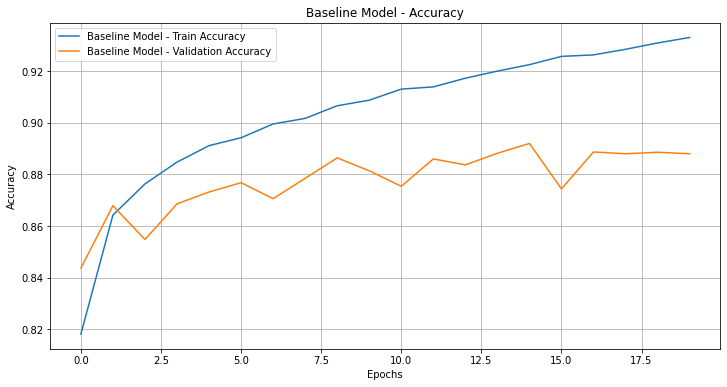

In [3]:
def create_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

baseline_model = create_baseline_model()
history_baseline = baseline_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20, batch_size=64)
plot_history(history_baseline, "Baseline Model")

## 2. Model with Batch Normalization

Epoch 1/20
938/938 [==============================] - 4s 3ms/step - loss: 0.4687 - accuracy: 0.8335 - val_loss: 0.4343 - val_accuracy: 0.8408
Epoch 2/20
938/938 [==============================] - 2s 2ms/step - loss: 0.3609 - accuracy: 0.8690 - val_loss: 0.4278 - val_accuracy: 0.8493
Epoch 3/20
938/938 [==============================] - 2s 3ms/step - loss: 0.3336 - accuracy: 0.8782 - val_loss: 0.4032 - val_accuracy: 0.8533
Epoch 4/20
938/938 [==============================] - 3s 3ms/step - loss: 0.3131 - accuracy: 0.8841 - val_loss: 0.3674 - val_accuracy: 0.8686
Epoch 5/20
938/938 [==============================] - 3s 3ms/step - loss: 0.3049 - accuracy: 0.8875 - val_loss: 0.4233 - val_accuracy: 0.8546
Epoch 6/20
938/938 [==============================] - 3s 3ms/step - loss: 0.2889 - accuracy: 0.8925 - val_loss: 0.3584 - val_accuracy: 0.8724
Epoch 7/20
938/938 [==============================] - 3s 3ms/step - loss: 0.2786 - accuracy: 0.8964 - val_loss: 0.3513 - val_accuracy: 0.8750
Epoch 

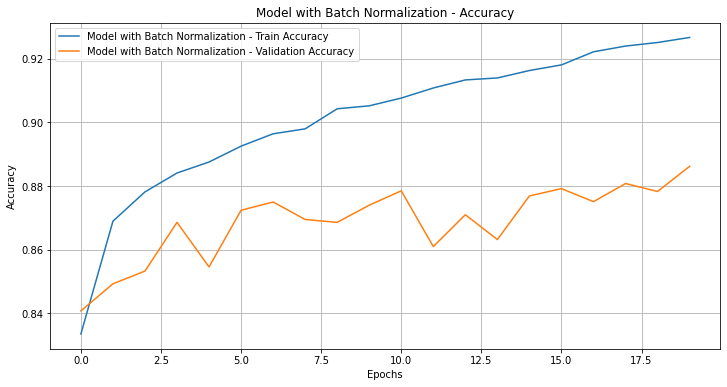

In [4]:
def create_bn_model():
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

bn_model = create_bn_model()
history_bn = bn_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20, batch_size=64)
plot_history(history_bn, "Model with Batch Normalization")

## Evaluation and Comparison
### Comparing Training and Validation Accuracy

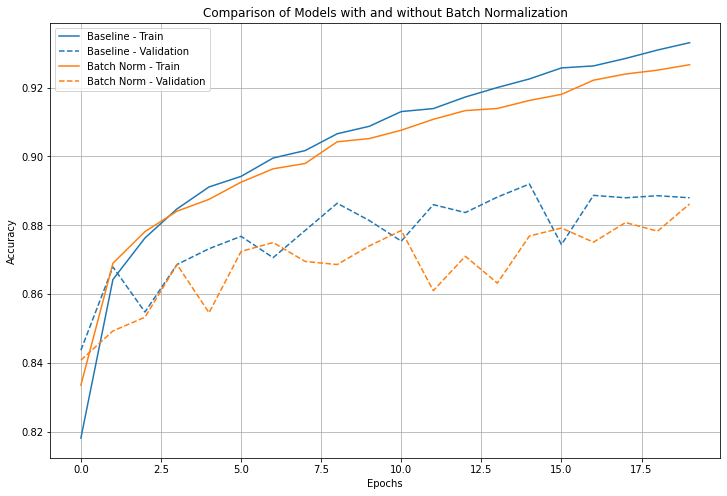

In [5]:
# Plot both models on the same graph for comparison
plt.figure(figsize=(12, 8))

# Baseline Model
plt.plot(history_baseline.history['accuracy'], label='Baseline - Train', color='#1f77b4', linestyle='-')
plt.plot(history_baseline.history['val_accuracy'], label='Baseline - Validation', color='#1f77b4', linestyle='--')

# Model with Batch Normalization
plt.plot(history_bn.history['accuracy'], label='Batch Norm - Train', color='#ff7f0e', linestyle='-')
plt.plot(history_bn.history['val_accuracy'], label='Batch Norm - Validation', color='#ff7f0e', linestyle='--')

plt.title('Comparison of Models with and without Batch Normalization')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()